# Podstawy Gymnasium: CliffWalking

## Środowisko Dyskretne

W tej części projektu wykorzystano klasyczny algorytm tablicowy **Q-Learning** do rozwiązania środowiska `CliffWalking-v0` z biblioteki Gymnasium. 

Środowisko to charakteryzuje się w pełni dyskretną przestrzenią obserwacji (siatka $4 \times 12$) oraz dyskretną przestrzenią akcji (4 kierunki ruchu).

Zgodnie z poleceniem[cite: 11], przyjęto współczynnik dyskontowy rzędu **$\gamma = 0.9$**. 

Poniższe komórki zawierają kod ładujący środowisko, przeprowadzający proces uczenia oraz wizualizujący wyniki przeprowadzonych eksperymentów.

In [11]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from q_learning_agent import QLearningAgent

print(f"Wersja Gymnasium: {gym.__version__}")

Wersja Gymnasium: 1.2.3


## 1. Definicja funkcji trenującej agenta

Aby uniknąć duplikowania kodu podczas przeprowadzania eksperymentów, główna pętla uczenia (Reinforcement Learning loop) została zamknięta w funkcji `train_agent()`. Funkcja ta przyjmuje jako parametry wszystkie hiperparametry algorytmu Q-Learning i zwraca zbiór zebranych nagród oraz przebieg wygaszania parametru eksploracji (epsilon).

In [12]:
def train_agent(env_name="CliffWalking-v1", n_episodes=500, learning_rate=0.1, discount_factor=0.9, 
                start_epsilon=1.0, epsilon_decay=0.99, min_epsilon=0.01):
    
    # Inicjalizacja środowiska
    env = gym.make(env_name)
    
    # Inicjalizacja naszego Agenta
    agent = QLearningAgent(
        n_states=env.observation_space.n, 
        n_actions=env.action_space.n, 
        learning_rate=learning_rate, 
        discount_factor=discount_factor, 
        epsilon=start_epsilon, 
        epsilon_decay=epsilon_decay, 
        min_epsilon=min_epsilon
    )

    rewards_per_episode = []
    epsilons_per_episode = []

    for episode in range(n_episodes):
        state, info = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            # Aktualizacja Tablicy Q
            agent.update(state, action, reward, next_state, terminated)
            
            state = next_state
            total_reward += reward
            
        rewards_per_episode.append(total_reward)
        epsilons_per_episode.append(agent.epsilon)
        
        agent.decay_epsilon()

    env.close()
    return rewards_per_episode, epsilons_per_episode

## 2. Eksperyment: Wpływ strategii eksploracji na uczenie agenta

W poniższej komórce przeprowadzamy badanie trzech podejść do strategii $\epsilon$-greedy:
1. **Brak wygaszania (Stały $\epsilon=0.1$):** Agent przez cały proces uczenia utrzymuje ryzyko wykonania losowego kroku na poziomie 10%. Z racji specyfiki środowiska (surowa kara -100 pkt za każdy upadek), spodziewamy się, że agent nigdy nie osiągnie całkowicie stabilnego stanu.
2. **Szybkie wygaszanie:** Parametr spada niemal do zera po około 100-150 epizodach.
3. **Wolne wygaszanie:** Parametr wolniej zbliża się do minimum, dając agentowi więcej czasu na upewnienie się co do wartości stanów na obrzeżach optymalnej ścieżki.

In [13]:
print("Uruchamianie eksperymentów...")

# Eksperyment 1: Stały Epsilon
rewards_const, eps_const = train_agent(
    start_epsilon=0.1, 
    epsilon_decay=1.0,  # Decay 1.0 oznacza brak spadku
    min_epsilon=0.1
)
print("✔ Ukończono: Stały Epsilon")

# Eksperyment 2: Szybkie wygaszanie
rewards_fast, eps_fast = train_agent(
    start_epsilon=1.0, 
    epsilon_decay=0.95, 
    min_epsilon=0.0
)
print("✔ Ukończono: Szybkie Wygaszanie")

# Eksperyment 3: Wolne wygaszanie
rewards_slow, eps_slow = train_agent(
    start_epsilon=1.0, 
    epsilon_decay=0.99, 
    min_epsilon=0.0
)
print("Ukończono: Wolne Wygaszanie")

Uruchamianie eksperymentów...
✔ Ukończono: Stały Epsilon
✔ Ukończono: Szybkie Wygaszanie
Ukończono: Wolne Wygaszanie


## 3. Wizualizacja Wyników Eksperymentu

Zebrane dane dla trzech konfiguracji umieszczamy na wspólnym wykresie, aby ułatwić ich porównanie.

*Uwaga na skalę osi Y: Aby ułatwić analizę wykresu we wczesnej fazie wygaszania (gdzie pojawiają się ekstremalne wyniki rzędu -200 000 spowodowane brakiem limitu kroków w CliffWalking), oś Y została celowo obcięta od dołu na poziomie -200 punktów.*

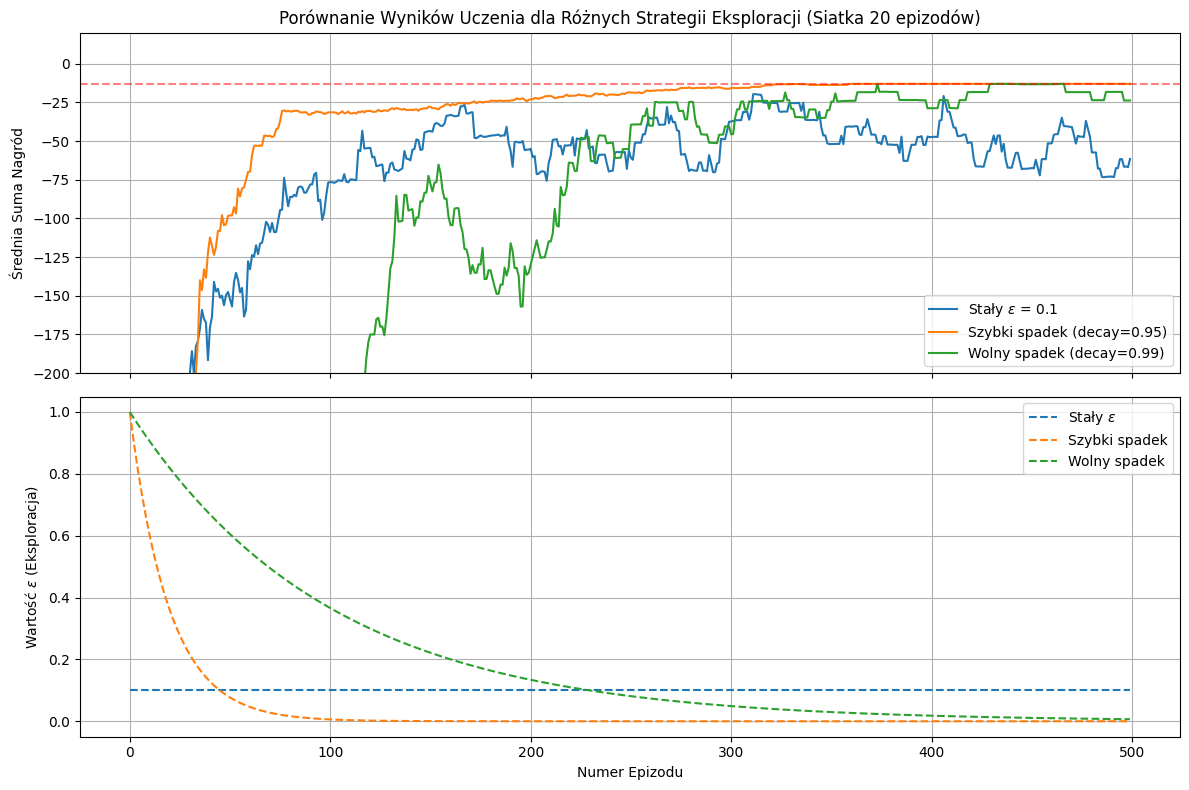

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

window = 20

# Wykres 1: Krzywe Uczenia
def smooth(data):
    return np.convolve(data, np.ones(window)/window, mode='valid')

ax1.plot(range(window-1, 500), smooth(rewards_const), label='Stały $\epsilon$ = 0.1', color='tab:blue')
ax1.plot(range(window-1, 500), smooth(rewards_fast), label='Szybki spadek (decay=0.95)', color='tab:orange')
ax1.plot(range(window-1, 500), smooth(rewards_slow), label='Wolny spadek (decay=0.99)', color='tab:green')

ax1.set_title('Porównanie Wyników Uczenia dla Różnych Strategii Eksploracji (Siatka 20 epizodów)')
ax1.set_ylabel('Średnia Suma Nagród')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(-200, 20) 

# Optymalna ścieżka (13 kroków)
ax1.axhline(y=-13, color='red', linestyle='--', alpha=0.5, label='Optimum (-13)')

# Wykres 2: Przebieg funkcji wygaszania (Epsilon)
ax2.plot(eps_const, label='Stały $\epsilon$', color='tab:blue', linestyle='dashed')
ax2.plot(eps_fast, label='Szybki spadek', color='tab:orange', linestyle='dashed')
ax2.plot(eps_slow, label='Wolny spadek', color='tab:green', linestyle='dashed')

ax2.set_xlabel('Numer Epizodu')
ax2.set_ylabel('Wartość $\epsilon$ (Eksploracja)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()